# Dark.Tyro M3 — the shield sweep

**One question: can PhotoGuard, in IMPRESS's own implementation, be pushed hard enough for
IMPRESS's own metric to notice it — without becoming visible?**

This notebook answers only that. It does **not** run the four wash arms; those are finished and
live in `run_0925_0152` (Colab, 25 Sep, all four arms on one shared protect stage).

### What it produces
- `shield_sweep.csv` — per image, per setting: `ssim_adv`, its seed floor, the margin, the verdict
- `shield_cost.csv` — what each shield costs: L2, L∞ in grey levels, LPIPS against the clean photo
- `m3_shield_curve.png` — the two axes on one figure: engagement bought, fidelity spent
- `REPORT_<run>.zip` — all of the above, mirrored to Drive as it is produced

### Run order
Cells top to bottom, once. **Runtime → Change runtime type → T4 GPU first.**

### Budget — measured, not guessed
| stage | cost |
|---|---:|
| cold-start setup (clone, pip, dataset, SD weights) | ~15 min |
| one fresh shield setting (protect 34 + edit 5) | ~39 min |
| row `(16, 1)` — reused from `run_0925_0152`, no GPU | ~1 min |
| scoring, cost table, figure, collect | ~4 min |
| **total for two fresh settings** | **≈ 1.5 h** |

Comfortably inside one free Colab session. The 25 Sep attempt died because it carried the four
arms (187 min) *and* the sweep in one session; this notebook carries only the sweep.

### Two warnings you can ignore when they appear
- `Error no file named diffusion_pytorch_model.safetensors ... Defaulting to unsafe serialization`
  — the checkpoint ships `.bin` for that component. It loads. Harmless.
- torchvision `pretrained is deprecated` from LPIPS. Harmless.

## Setup · cells 1–3

In [ ]:
# 1 · Platform, device, paths, Drive, and the exact versions this run used.
import os, sys, re, json, time, glob, shutil, zipfile, pathlib, subprocess, threading
import torch, numpy as np
from PIL import Image

BASE, PLATFORM = ((pathlib.Path('/kaggle/working'), 'kaggle') if os.path.isdir('/kaggle/working')
                  else (pathlib.Path('/content'), 'colab') if os.path.isdir('/content')
                  else (pathlib.Path.cwd(), 'local'))

# fp16 backward is unreliable off CUDA, so CPU runs fp32 (see the patch in cell 2).
DEVICE, USE_FP32 = ('cuda:0', False) if torch.cuda.is_available() else ('cpu', True)

IMPRESS_DIR = BASE / 'Impress'
ROOT        = BASE / 'helen_face'    # must stay a SIBLING of Impress/: the scripts use ../helen_face
ARCHIVE     = BASE / 'tyro_sweep'    # LOCAL disk. Drive receives finished files only — see cell 5.

SUBENV = dict(os.environ, PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True')

# Fail fast on an unsupported GPU rather than two minutes into a 34-minute stage.
GPU_OK = True
if DEVICE.startswith('cuda'):
    _tag   = 'sm_%d%d' % torch.cuda.get_device_capability(0)
    GPU_OK = _tag in torch.cuda.get_arch_list()
    print(f'gpu    : {torch.cuda.get_device_name(0)} ({_tag}) - torch {torch.__version__}')
    if not GPU_OK:
        print(f'!! this torch build has no kernels for {_tag}. Runtime -> Change runtime type -> T4 GPU.')
else:
    GPU_OK = False
    print('!! NO GPU FOUND. Runtime -> Change runtime type -> T4 GPU, then re-run this cell.')

# Persistence: Colab wipes the VM on disconnect. The working tree stays on LOCAL disk and only
# finished files are copied to Drive - building an image tree on a FUSE mount is thousands of
# small-file operations and costs minutes per row.
DRIVE_DIR = None
if PLATFORM == 'colab':
    try:
        from google.colab import drive; drive.mount('/content/drive')
        DRIVE_DIR = pathlib.Path('/content/drive/MyDrive/FIT5230_M3')
        DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print(f'!! Drive mount failed ({e}) - download tyro_sweep/ before the tab closes.')

RUN_TAG = globals().get('RUN_TAG') or time.strftime('sweep_%m%d_%H%M')
OUT = ARCHIVE / RUN_TAG
OUT.mkdir(parents=True, exist_ok=True)
print(f'{PLATFORM} - {DEVICE} - {"fp32" if USE_FP32 else "fp16"} - results -> {OUT}')
if DRIVE_DIR: print(f'mirrored -> {DRIVE_DIR / RUN_TAG}')

# Record the environment. IMPRESS's requirements.txt pins only transformers>=4.25.1, so
# "it worked last time" is not reproducible unless the versions are written down.
import importlib.metadata as _md
_env = {}
for _m in ('torch', 'diffusers', 'transformers', 'huggingface_hub', 'numpy', 'scikit-image', 'lpips'):
    try:    _env[_m] = _md.version(_m)
    except Exception: _env[_m] = 'not installed'
    print(f'   {_m:<16} {_env[_m]}')

gpu    : Tesla T4 (sm_75) - torch 2.11.0+cu128
Mounted at /content/drive
colab - cuda:0 - fp16 - results -> /content/tyro_sweep/sweep_0927_0210
mirrored -> /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210
   torch            2.11.0+cu128
   diffusers        0.40.0
   transformers     5.16.1
   huggingface_hub  1.29.0
   numpy            2.1.3
   scikit-image     0.25.2
   lpips            not installed


In [ ]:
# 2 · Clone IMPRESS, install what its requirements.txt omits, patch the 2023 source.
import importlib.util

# Worked on Colab 25 Sep 2026: diffusers 0.40.0, transformers 5.16.1, torch 2.11.0, numpy 2.1.3.
# Only pin if the pipeline throws on load - cell 1 prints what you actually got.
DIFFUSERS_PIN = ''                      # e.g. '==0.40.0'

# sewar: pg_metric imports it and requirements.txt omits it. gdown: the dataset link.
NODEPS = {'sewar': 'sewar', 'lpips': 'lpips', 'gdown': 'gdown', 'ftfy': 'ftfy',
          'diffusers': f'diffusers{DIFFUSERS_PIN}'}
missing = [pkg for mod, pkg in NODEPS.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run(f'pip install -q --no-deps {" ".join(missing)}', shell=True, check=False)
# scikit-image needs its dependencies, so it does NOT go through --no-deps.
if importlib.util.find_spec('skimage') is None:
    subprocess.run('pip install -q scikit-image', shell=True, check=False)
    missing.append('scikit-image')
print('installed:', missing or 'nothing needed')

if not IMPRESS_DIR.exists():
    subprocess.run(f'git clone -q --depth 1 https://github.com/AAAAAAsuka/Impress.git {IMPRESS_DIR}',
                   shell=True, check=True)

n = 0
for p in sorted(IMPRESS_DIR.glob('*.py')):
    s = orig = p.read_text()
    s = s.replace('runwayml/stable-diffusion-inpainting',                  # FIX 1: repo deleted
                  'stable-diffusion-v1-5/stable-diffusion-inpainting')
    s = re.sub(r'^[ \t]*revision="fp16",[ \t]*\r?\n', '', s, flags=re.M)   # FIX 2: no fp16 branch
    if USE_FP32:
        s = s.replace('torch.float16', 'torch.float32').replace('.half()', '.float()')
    if s != orig:
        p.write_text(s); n += 1
print(f'cloned + patched {n} files')
if n == 0 and IMPRESS_DIR.exists():
    print('   (0 patched = the clone was already patched earlier in this session. Fine.)')

installed: ['sewar', 'lpips', 'ftfy']
cloned + patched 6 files


In [ ]:
# 3 · The Helen face data, the PINNED ten, and their published seed floors.
import gdown

# A seed floor is SSIM between two edits of the SAME clean image at two different seeds, with no
# protection anywhere. It is how much this editor moves on its own. Below that number, "the edit
# changed" stops meaning anything.
#   Metaphor: the floors are how loud each room already is. You cannot claim you were heard in a
#   room where you were quieter than the background noise.
# Measured 2026-09-10 (M2 Tyro_M2_diagnostics.ipynb, cell D4) and published with the challenge as
# challenge/tyro_wash_test_trackA/seed_floor_10.json. They are NOT re-measured here: the scoring
# runbook depends on them, and changing a public artefact to flatter our own number is the move we
# would criticise in another team.
SEED_FLOOR = {
    '1233476865_1.png': 0.4721, '1525918600_1.png': 0.4149, '178046512_1.png' : 0.4800,
    '181707205_1.png' : 0.5620, '1961032923_1.png': 0.7067, '2061993362_1.png': 0.4360,
    '2099073485_1.png': 0.3757, '2139626906_1.png': 0.3165, '2167874246_1.png': 0.2849,
    '221629697_1.png' : 0.3159,
}
N_IMAGES = 10      # >= 2, or pg_metric's torch.std() returns nan. Ten is the published pack.

zip_path = BASE / 'helen_face_dataset.zip'
if not zip_path.exists():
    gdown.download(id='16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl', output=str(zip_path), quiet=True)
if not (ROOT / 'clean').exists():
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as z: z.extractall(ROOT)

avail = set(os.listdir(ROOT / 'clean'))
keep  = [n for n in SEED_FLOOR if n in avail][:N_IMAGES]
assert len(keep) == N_IMAGES, f'only {len(keep)} of the pinned ten are in the zip - stop and check'
keep = set(keep)
for sub in ('clean', 'mask'):                      # clean/ and mask/ stay in sync
    for f in os.listdir(ROOT / sub):
        if f not in keep: os.remove(ROOT / sub / f)

_fl = [SEED_FLOOR[n] for n in sorted(keep)]
print(f'{len(keep)} faces pinned - seed floors {min(_fl):.4f}-{max(_fl):.4f} '
      f'({max(_fl)/min(_fl):.1f}x spread)')
for n in sorted(keep): print(f'   {n:<20} floor {SEED_FLOOR[n]:.4f}')

10 faces pinned - seed floors 0.2849-0.7067 (2.5x spread)
   1233476865_1.png     floor 0.4721
   1525918600_1.png     floor 0.4149
   178046512_1.png      floor 0.4800
   181707205_1.png      floor 0.5620
   1961032923_1.png     floor 0.7067
   2061993362_1.png     floor 0.4360
   2099073485_1.png     floor 0.3757
   2139626906_1.png     floor 0.3165
   2167874246_1.png     floor 0.2849
   221629697_1.png      floor 0.3159


## The experiment

The four wash arms asked *how much of the shield's damage can a wash undo?* That question has an
answer only if the shield did damage. It did not: across four independent runs at the M2 setting,
**0–1 of ten images** cleared their seed floor, and the one that did is not reproducible.

So this notebook stops varying the wash and varies **the shield** instead. One knob at a time,
both axes always:

| axis | measured by | question |
|---|---|---|
| **engagement** | `ssim_adv` vs the published seed floor | does IMPRESS's own metric notice the shield? |
| **cost** | L2, L∞ grey levels, LPIPS vs the clean photo | what did the photograph pay for it? |

Engagement alone is a one-axis score, and a one-axis score always has a degenerate winner: push the
shield until the photograph is ruined and it will certainly be "detected". Both axes, always — the
same rule the Tyro Wash Test holds challengers to, applied here to our own shield.

**Every row is a null arm.** No purification runs anywhere in this notebook. `purified/` is a copy
of `protected/`, so the edit stage runs byte-identical code on both and the wash cannot contaminate
a measurement about the shield.

In [ ]:
# 4 · SETTINGS - the only cell you edit.
PARAMS = dict(attack_type='l2', pg_eps=16, pg_step_size=1, pg_eta=1, diff_steps=4, guidance=7.5,
              seed=0, pur_eps=0.1, pur_iters=0, pur_lr=0.005, pur_alpha=0.01, pur_noise=0.05,
              prompt='a person in an airplane', test_guidance=7.5, test_diff_steps=50)
PG_ITERS, PG_REPS = 40, 2          # the shield's iteration budget, fixed across the grid

# (pg_eps, pg_step_size). Three points make a curve; two make a line through one gradient.
# The pg_step_size rows (16,2)/(16,4)/(16,8) are SETTLED - it re-randomises, it does not steer -
# and archived from run_0919_2319. They belong in the appendix, not in 2 h of this run.
SHIELD_GRID = [(16, 1), (64, 4), (256, 4)]

# Row (16,1) IS the four-arm setting, already measured at n=10 in run_0925_0152. Re-running it
# would spend 39 min on a number we own. This reads it out of that run's archive instead, and
# every row carries measured_here = True/False so the provenance travels with the data.
# Set REUSE_16_1 = None to measure it here as well.
REUSE_16_1 = '/content/drive/MyDrive/FIT5230_M3/run_0925_0152/N_no_wash.zip'

# The gate band. 0.010 is the PUBLISHED value, calibrated from cross-platform drift (~0.004 each
# side). Four same-setting runs since measured the real spread at ~0.027 median range. Cell 7
# prints the counts at BOTH, so widening the band stays a visible decision, not a silent one.
DRIFT, DRIFT_WIDE = 0.010, 0.027

BUDGET_LPIPS = 0.10               # our own published challenger ceiling

_fresh = [g for g in SHIELD_GRID if not (REUSE_16_1 and g == (16, 1))]
print(f'grid            {SHIELD_GRID}')
print(f'measured here   {_fresh}   ({len(_fresh)} x ~39 min)')
if REUSE_16_1: print(f'reused          (16, 1) <- {REUSE_16_1}')
print(f'gate band       DRIFT={DRIFT}  (also reported at {DRIFT_WIDE})')
print(f'\nbudget: ~15 min setup + {len(_fresh)} x 39 min + ~4 min tables '
      f'= ~{(15 + len(_fresh) * 39 + 4) / 60:.1f} h')
if (15 + len(_fresh) * 39 + 4) / 60 > 3.5:
    print('   !! over 3.5 h - free Colab is unlikely to hold this in one session.')

grid            [(16, 1), (64, 4), (256, 4)]
measured here   [(64, 4), (256, 4)]   (2 x ~39 min)
reused          (16, 1) <- /content/drive/MyDrive/FIT5230_M3/run_0925_0152/N_no_wash.zip
gate band       DRIFT=0.01  (also reported at 0.027)

budget: ~15 min setup + 2 x 39 min + ~4 min tables = ~1.6 h


## The harness

One shield setting per row. Each row: protect → copy protected to purified (the null) → edit all
three variants → archive and zip → mirror the zip to Drive.

`pg_metric.py` is **not** run. The sweep scores itself with `ssim_pair` below, and IMPRESS's
`pg_metric` computes SSIM under a different convention that reads about **+0.019** higher on the
same images. Mixing the two is how two tables in one notebook end up disagreeing — and the seed
floors were measured with `ssim_pair`'s convention, so that is the one the gate must use.

In [ ]:
# 5 · Harness.
from skimage.metrics import structural_similarity as _ssim
import pandas as pd
P = PARAMS

# ssim_pair is the SAME estimator the published seed floors were measured with (M2
# Tyro_M2_diagnostics.ipynb cell D4: skimage structural_similarity, channel_axis=2,
# data_range=255). Do not swap it for pg_metric's - they differ by a systematic ~0.019, which is
# larger than the gate band and would flip verdicts.
def ssim_pair(pa, pb):
    a = np.asarray(Image.open(pa).convert('RGB'), np.uint8)
    b = np.asarray(Image.open(pb).convert('RGB'), np.uint8)
    if a.shape != b.shape:                     # FIX 12: resample toward the SMALLER image
        h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
        a = np.asarray(Image.fromarray(a).resize((w, h)))
        b = np.asarray(Image.fromarray(b).resize((w, h)))
    return float(_ssim(a, b, channel_axis=2, data_range=255))

# Three-state gate. A margin smaller than the measurement's own spread is not a decision.
def gate(ssim_adv, floor, drift=None):
    d = DRIFT if drift is None else drift
    if floor is None or floor != floor:
        return dict(margin=float('nan'), verdict='NO FLOOR')
    m = ssim_adv - floor
    return dict(margin=round(m, 4),
                verdict='INDETERMINATE' if abs(m) < d else ('ENGAGED' if m < 0 else 'BLIND'))

# FIX 8: rebuild these from parameters - never glob for them. eps and step are ARGUMENTS here, not
# read from a mutated global, which removes the whole class of bug where a stale command string
# runs one setting while every label says another.
def adv_dir(eps, step):
    return (f"{ROOT}/adv_{P['attack_type']}_eps{eps}_step{step}"
            f"_iter{PG_ITERS}grad_reps{PG_REPS}_eta{P['pg_eta']}_diff_steps{P['diff_steps']}"
            f"_guidance{P['guidance']}_seed{P['seed']}")
adapt_dir    = lambda e, s: adv_dir(e, s).replace('/adv_', '/adapt_adv_')
adv_diff_dir = lambda e, s: re.sub('adv', 'adv_diff', adv_dir(e, s))
pur_dir      = lambda: (f"{ROOT}/pur_eps{P['pur_eps']}_pur_iters{P['pur_iters']}_pur_lr{P['pur_lr']}"
                        f"_pur_alpha{P['pur_alpha']}_pur_noise{P['pur_noise']}/")
pur_diff_dir = lambda: re.sub('pur', 'pur_diff', pur_dir())

def mirror(path):
    # One sequential copy of a finished file to Drive. No-op off Colab. Never fatal.
    if not DRIVE_DIR: return path
    try:
        d = DRIVE_DIR / RUN_TAG; d.mkdir(parents=True, exist_ok=True)
        shutil.copy(path, d / os.path.basename(path))
        print(f'   [drive] {d / os.path.basename(path)}', flush=True)
    except Exception as e:
        print(f'   !! drive mirror failed ({e}) - local copy intact at {path}', flush=True)
    return path

def sh(cmd, eta_min=None):
    # Prints an ETA before it goes quiet. The 25 Sep run looked frozen for 33 minutes because a
    # 60-second heartbeat with no expected duration is indistinguishable from a hang.
    print(f'$ {cmd}', flush=True)
    if eta_min: print(f'   expect ~{eta_min} min. The heartbeat below is the only sign of life.', flush=True)
    t0, stop = time.time(), threading.Event()
    def _beat():
        while not stop.wait(120):
            el = (time.time() - t0) / 60
            print(f'   ... {el:.1f}' + (f' of ~{eta_min}' if eta_min else '') + ' min', flush=True)
    threading.Thread(target=_beat, daemon=True).start()
    try:
        r = subprocess.run(f'{sys.executable} -u {cmd}', shell=True, cwd=str(IMPRESS_DIR),
                           env=SUBENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    finally:
        stop.set()
    print(r.stdout[-1500:], f'\n   [{(time.time()-t0)/60:.1f} min]', flush=True)
    # The old harness only checked that an output folder appeared. A non-zero exit now stops the
    # row instead of letting a half-finished setting into the table.
    if r.returncode != 0:
        raise RuntimeError(f'{cmd.split()[0]} exited {r.returncode} - see the tail above')
    return r.stdout

def archive_row(dest, eps, step, measured_here=True):
    # Only the four folders the sweep and the cost table read. The four-arm harness archived seven,
    # two of which are duplicates for a null arm - that was ~45% of the zip for nothing.
    dest.mkdir(parents=True, exist_ok=True)
    (dest / 'clean512').mkdir(exist_ok=True)
    for f in sorted(glob.glob(f'{ROOT}/clean/*.png')):
        # FIX 12: archive the 512x512 tensor the pipeline conditioned on, not the original.
        Image.open(f).convert('RGB').resize((512, 512)).save(dest / 'clean512' / os.path.basename(f))
    for name, path in [('protected',      adv_dir(eps, step)),
                       ('edit_clean',     f'{ROOT}/clean_diff'),
                       ('edit_protected', adv_diff_dir(eps, step))]:
        assert os.path.isdir(path), f'missing {name} at {path}'
        shutil.copytree(path, dest / name, dirs_exist_ok=True)
    (dest / 'params.json').write_text(json.dumps(
        {**P, 'pg_eps': eps, 'pg_step_size': step, 'pg_iters': PG_ITERS, 'pg_grad_reps': PG_REPS,
         'measured_here': measured_here, 'platform': PLATFORM, 'run_tag': RUN_TAG,
         'env': _env}, indent=2))
    mirror(shutil.make_archive(str(OUT / f'S_eps{eps}_step{step}'), 'zip', root_dir=str(dest)))

def run_shield(eps, step):
    tag, dest = f'S_eps{eps}_step{step}', OUT / f'S_eps{eps}_step{step}'
    if (dest / 'edit_protected').is_dir():
        print(f'   {tag}: already archived, skipping (delete the folder to force a re-run)')
        return dest
    print('=' * 70, f'\n  SHIELD {tag}   (eps={eps}, step={step}, null arm)\n', '=' * 70, flush=True)
    t0 = time.time()
    PG  = (f"--attack_type={P['attack_type']} --pg_eps={eps} --pg_step_size={step} "
           f"--pg_eta={P['pg_eta']} --parallel_index=-1 --device={DEVICE}")   # FIX 4: -1 disables sharding
    PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
           f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")
    common = (f"{PG} --pg_iters={PG_ITERS} --pg_grad_reps={PG_REPS} "
              f"--diff_steps={P['diff_steps']} --guidance={P['guidance']}")

    # (a) protect - PhotoGuard. Skips images already done, so an interrupted row resumes.
    sh(f'pg_mask_diff_helen.py {common}', eta_min=34)
    src = adv_dir(eps, step)
    assert os.path.isdir(src), f'protect produced nothing at {src}'

    # (b) FIX 5: bridge the broken folder contract between the protect and edit stages.
    dst = adapt_dir(eps, step)
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.copytree(src, dst)

    # (c) the NULL: purified/ = protected/. FIX 7 - clear the folder first, or this row silently
    #     reports the previous row's images.
    for stale in (pur_dir(), pur_diff_dir()):
        if os.path.exists(stale): shutil.rmtree(stale)
    os.makedirs(pur_dir(), exist_ok=True)
    for f in sorted(glob.glob(f'{src}/*.png')): shutil.copy(f, pur_dir())

    # (d) edit. FIX 6: diff_steps forced through, or the output folder name is wrong.
    sh(f'pg_generate.py {common} {PUR} --test_guidance={P["test_guidance"]} '
       f'--test_diff_steps={P["test_diff_steps"]} --prompt="{P["prompt"]}"', eta_min=5)

    archive_row(dest, eps, step, measured_here=True)
    print(f'[done] {tag} ({(time.time()-t0)/60:.1f} min)', flush=True)
    return dest

def reuse_row(zip_path, eps, step):
    tag, dest = f'S_eps{eps}_step{step}', OUT / f'S_eps{eps}_step{step}'
    if (dest / 'edit_protected').is_dir():
        print(f'   {tag}: already unpacked'); return dest
    dest.mkdir(parents=True, exist_ok=True)
    wanted = ('clean512', 'protected', 'edit_clean', 'edit_protected')
    with zipfile.ZipFile(zip_path) as z:
        for m in z.namelist():
            if m.split('/')[0] in wanted: z.extract(m, dest)
    for w in wanted:
        assert (dest / w).is_dir(), f'{zip_path} has no {w}/ - set REUSE_16_1 = None and measure it'
    (dest / 'params.json').write_text(json.dumps(
        dict(pg_eps=eps, pg_step_size=step, pg_iters=PG_ITERS, pg_grad_reps=PG_REPS,
             measured_here=False, source=str(zip_path), run_tag=RUN_TAG), indent=2))
    k = len(list((dest / 'edit_protected').glob('*.png')))
    print(f'   {tag}: REUSED - {k} images from {os.path.basename(zip_path)}, 0 GPU, '
          f'measured_here=False')
    return dest

print('harness ready - null arm only, no purification, no pg_metric')

harness ready - null arm only, no purification, no pg_metric


In [ ]:
# 6 · RUN the grid. Each row archives and zips itself, so a disconnect costs one row.
assert GPU_OK, 'no usable GPU - Runtime -> Change runtime type -> T4 GPU, then re-run cell 1'

for _eps, _step in SHIELD_GRID:
    if REUSE_16_1 and (_eps, _step) == (16, 1):
        if os.path.exists(REUSE_16_1):
            reuse_row(REUSE_16_1, _eps, _step); continue
        print(f'!! REUSE_16_1 not found at {REUSE_16_1}\n'
              f'   measuring this row here instead (+39 min)')
    run_shield(_eps, _step)

print('\nrows present:', sorted(p.name for p in OUT.glob('S_eps*') if p.is_dir()))

   S_eps16_step1: REUSED - 10 images from N_no_wash.zip, 0 GPU, measured_here=False
  SHIELD S_eps64_step4   (eps=64, step=4, null arm)
$ pg_mask_diff_helen.py --attack_type=l2 --pg_eps=64 --pg_step_size=4 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5
   expect ~34 min. The heartbeat below is the only sign of life.
   ... 2.0 of ~34 min
   ... 4.0 of ~34 min
   ... 6.0 of ~34 min
   ... 8.0 of ~34 min
   ... 10.0 of ~34 min
   ... 12.0 of ~34 min
   ... 14.0 of ~34 min
   ... 16.0 of ~34 min
   ... 18.0 of ~34 min
   ... 20.0 of ~34 min
   ... 22.0 of ~34 min
   ... 24.0 of ~34 min
   ... 26.0 of ~34 min
   ... 28.0 of ~34 min
   ... 30.0 of ~34 min
   ... 32.0 of ~34 min
   ... 34.0 of ~34 min
 [02:25<00:53,  4.85s/it]
AVG Loss: 696.151: 100%|██████████| 40/40 [03:13<00:00,  4.85s/it]
 
   [34.4 min]
$ pg_generate.py --attack_type=l2 --pg_eps=64 --pg_step_size=4 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 -

## Reading the numbers

`ssim_adv` is SSIM between the edit of the **protected** photo and the edit of the **clean** photo,
at the same seed, same prompt, same mask.

- If the shield did nothing, `ssim_adv` would be **1.0000** — identical inputs through a
  deterministic editor. It is not, so the shield does change the edit.
- The seed floor asks a different question: does it change it **more than a seed change does?**

`margin = ssim_adv − floor`. Negative means the shield out-moved the editor's own jitter, which is
the only condition under which `R_pipe` has a denominator worth quoting.

In [ ]:
# 7 · Score every setting against the published per-image seed floors.
rows = []
for _eps, _step in SHIELD_GRID:
    d = OUT / f'S_eps{_eps}_step{_step}'
    if not (d / 'edit_clean').is_dir(): continue
    here = json.loads((d / 'params.json').read_text()).get('measured_here', True)
    for n in sorted(os.listdir(d / 'edit_clean')):
        pa, pb = d / 'edit_protected' / n, d / 'edit_clean' / n
        if not (pa.exists() and pb.exists()): continue
        a, f = ssim_pair(pa, pb), SEED_FLOOR.get(n)
        rows.append(dict(pg_eps=_eps, pg_step_size=_step, image=n, ssim_adv=round(a, 4),
                         floor=f if f is not None else float('nan'), measured_here=here,
                         **gate(a, f), verdict_wide=gate(a, f, DRIFT_WIDE)['verdict']))

sweep = pd.DataFrame(rows)
display(sweep)
assert not sweep.empty, 'no rows scored - check cell 6 finished'
sweep.to_csv(OUT / 'shield_sweep.csv', index=False); mirror(OUT / 'shield_sweep.csv')

def _counts(col):
    print(f'\nsetting            ENGAGED  indet  BLIND   median margin   provenance')
    for (e, s), g in sweep.groupby(['pg_eps', 'pg_step_size'], sort=False):
        c = g[col].value_counts()
        prov = 'measured here' if g.measured_here.all() else 'REUSED'
        print(f'   eps {e:>3}, step {s:<2}   {c.get("ENGAGED",0):>5}  {c.get("INDETERMINATE",0):>5}'
              f'  {c.get("BLIND",0):>5}   {g.margin.median():+.4f}         {prov}')

print(f'=== gate at the PUBLISHED band, DRIFT = {DRIFT} ===');      _counts('verdict')
print(f'\n=== same data at the MEASURED spread, {DRIFT_WIDE} ==='); _counts('verdict_wide')
print('\nWiden the band and the counts should barely move. If they do not, the conclusion does not'
      '\ndepend on a band we chose - which is the point of printing both.')

,pg_eps,pg_step_size,image,ssim_adv,floor,measured_here,margin,verdict,verdict_wide
0,16,1,1233476865_1.png,0.5786,0.4721,False,0.1065,BLIND,BLIND
1,16,1,1525918600_1.png,0.6410,0.4149,False,0.2261,BLIND,BLIND
2,16,1,178046512_1.png,0.5584,0.4800,False,0.0784,BLIND,BLIND
3,16,1,181707205_1.png,0.5864,0.5620,False,0.0244,BLIND,INDETERMINATE
4,16,1,1961032923_1.png,0.6942,0.7067,False,-0.0125,ENGAGED,INDETERMINATE
5,16,1,2061993362_1.png,0.4898,0.4360,False,0.0538,BLIND,BLIND
6,16,1,2099073485_1.png,0.5315,0.3757,False,0.1558,BLIND,BLIND
7,16,1,2139626906_1.png,0.3828,0.3165,False,0.0663,BLIND,BLIND
8,16,1,2167874246_1.png,0.4471,0.2849,False,0.1622,BLIND,BLIND
9,16,1,221629697_1.png,0.4822,0.3159,False,0.1663,BLIND,BLIND


   [drive] /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210/shield_sweep.csv
=== gate at the PUBLISHED band, DRIFT = 0.01 ===

setting            ENGAGED  indet  BLIND   median margin   provenance
   eps  16, step 1        1      0      9   +0.0925         REUSED
   eps  64, step 4        2      3      5   +0.0219         measured here
   eps 256, step 4        1      2      7   +0.0362         measured here

=== same data at the MEASURED spread, 0.027 ===

setting            ENGAGED  indet  BLIND   median margin   provenance
   eps  16, step 1        0      2      8   +0.0925         REUSED
   eps  64, step 4        2      3      5   +0.0219         measured here
   eps 256, step 4        1      3      6   +0.0362         measured here

Widen the band and the counts should barely move. If they do not, the conclusion does not
depend on a band we chose - which is the point of printing both.


In [ ]:
# 8 · What each shield COSTS. Reads archived PNGs only - no GPU, no editor.
#     Engagement alone is a one-axis score, and a one-axis score has a degenerate winner.
import lpips as _lpips, torch as _t
_net = _lpips.LPIPS(net='alex').to(DEVICE).eval()

def _lp(a, b):
    f = lambda q: (_t.from_numpy(np.asarray(Image.open(q).convert('RGB'), np.float32) / 127.5 - 1)
                   .permute(2, 0, 1)[None].to(DEVICE))
    with _t.no_grad(): return float(_net(f(a), f(b)))

def _delta(prot_p, clean_p):
    a = np.asarray(Image.open(prot_p ).convert('RGB'), np.float32)
    b = np.asarray(Image.open(clean_p).convert('RGB').resize(a.shape[1::-1]), np.float32)
    d = a - b
    return float(np.sqrt((d ** 2).sum())), float(np.abs(d).max())

rows = []
for _eps, _step in SHIELD_GRID:
    d = OUT / f'S_eps{_eps}_step{_step}'
    if not (d / 'protected').is_dir(): continue
    for n in sorted(os.listdir(d / 'protected')):
        c = d / 'clean512' / n
        if not c.exists(): continue
        l2, linf = _delta(d / 'protected' / n, c)
        rows.append(dict(pg_eps=_eps, pg_step_size=_step, image=n, L2=round(l2, 1),
                         Linf_levels=round(linf, 1),
                         shield_lpips=round(_lp(d / 'protected' / n, c), 4)))

cost = pd.DataFrame(rows)
display(cost)
assert not cost.empty, 'no archives - run cell 6 first'
cost.to_csv(OUT / 'shield_cost.csv', index=False); mirror(OUT / 'shield_cost.csv')

print(f'\nBUDGET = LPIPS <= {BUDGET_LPIPS}, the same ceiling we publish for challengers.\n')
print('setting            L2 med   Linf med   LPIPS med   over budget')
for (e, s), g in cost.groupby(['pg_eps', 'pg_step_size'], sort=False):
    med = g.shield_lpips.median()
    print(f'   eps {e:>3}, step {s:<2}  {g.L2.median():>7.0f}   {g.Linf_levels.median():>7.0f}'
          f'   {med:>9.4f}   {int((g.shield_lpips > BUDGET_LPIPS).sum())}/{len(g)}'
          f'{"   <-- OVER" if med > BUDGET_LPIPS else ""}')
print('\nL-inf is in grey levels out of 255. A shield you can see has already failed at being a'
      '\nshield, whatever the engagement count says.')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 171MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


,pg_eps,pg_step_size,image,L2,Linf_levels,shield_lpips
0,16,1,1233476865_1.png,2645.7,51.0,0.0179
1,16,1,1525918600_1.png,1840.2,59.0,0.0166
2,16,1,178046512_1.png,3251.9,61.0,0.0402
3,16,1,181707205_1.png,5344.8,62.0,0.0511
4,16,1,1961032923_1.png,3862.4,60.0,0.0744
5,16,1,2061993362_1.png,1695.3,39.0,0.0199
6,16,1,2099073485_1.png,1892.6,60.0,0.0102
7,16,1,2139626906_1.png,6416.2,62.0,0.0684
8,16,1,2167874246_1.png,2899.8,61.0,0.0341
9,16,1,221629697_1.png,2090.3,64.0,0.0079


   [drive] /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210/shield_cost.csv

BUDGET = LPIPS <= 0.1, the same ceiling we publish for challengers.

setting            L2 med   Linf med   LPIPS med   over budget
   eps  16, step 1      2773        60      0.0270   0/10
   eps  64, step 4      3836       100      0.0964   3/10
   eps 256, step 4      3870        96      0.0985   3/10

L-inf is in grey levels out of 255. A shield you can see has already failed at being a
shield, whatever the engagement count says.


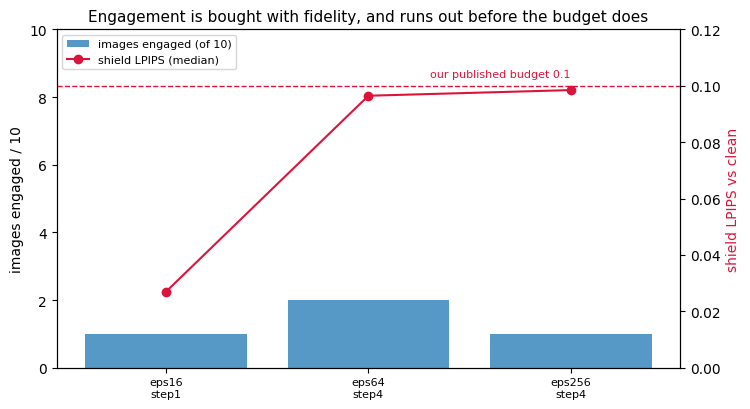

   [drive] /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210/m3_shield_curve.png


PosixPath('/content/tyro_sweep/sweep_0927_0210/m3_shield_curve.png')

In [ ]:
# 9 · The figure. Both axes on one plot - the M3 headline.
#     Same design as m3_shield_curve.png in run_0919_2319, so the two are directly comparable.
import matplotlib.pyplot as plt

lbl = [f'eps{e}\nstep{s}' for e, s in SHIELD_GRID]
eng = [int((sweep[(sweep.pg_eps == e) & (sweep.pg_step_size == s)].verdict == 'ENGAGED').sum())
       for e, s in SHIELD_GRID]
lp  = [cost[(cost.pg_eps == e) & (cost.pg_step_size == s)].shield_lpips.median()
       for e, s in SHIELD_GRID]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(range(len(lbl)), eng, color='C0', alpha=.75, label=f'images engaged (of {N_IMAGES})')
ax.set_ylabel(f'images engaged / {N_IMAGES}'); ax.set_ylim(0, N_IMAGES)
ax.set_xticks(range(len(lbl))); ax.set_xticklabels(lbl, fontsize=8)
ax2 = ax.twinx()
ax2.plot(range(len(lbl)), lp, 'o-', color='crimson', label='shield LPIPS (median)')
ax2.axhline(BUDGET_LPIPS, color='crimson', ls='--', lw=1)
ax2.text(len(lbl) - 1, BUDGET_LPIPS + 0.003, f'our published budget {BUDGET_LPIPS}',
         ha='right', color='crimson', fontsize=8)
ax2.set_ylabel('shield LPIPS vs clean', color='crimson')
ax2.set_ylim(0, max(BUDGET_LPIPS * 1.2, max(lp) * 1.15))
ax.set_title('Engagement is bought with fidelity, and runs out before the budget does', fontsize=11)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'm3_shield_curve.png', dpi=110, bbox_inches='tight'); plt.show()
mirror(OUT / 'm3_shield_curve.png')

In [ ]:
# 10 · Collect - one small zip with everything a reader needs, and nothing they don't.
REPORT = OUT / f'REPORT_{RUN_TAG}'
REPORT.mkdir(parents=True, exist_ok=True)

for f in ('shield_sweep.csv', 'shield_cost.csv', 'm3_shield_curve.png'):
    if (OUT / f).exists(): shutil.copy(OUT / f, REPORT / f)
for _eps, _step in SHIELD_GRID:
    src = OUT / f'S_eps{_eps}_step{_step}' / 'params.json'
    if src.exists(): shutil.copy(src, REPORT / f'S_eps{_eps}_step{_step}__params.json')

with open(REPORT / 'gate.txt', 'w') as fh:
    fh.write(f'run {RUN_TAG} - {PLATFORM} - N_IMAGES={N_IMAGES} - shield ({PG_ITERS}, {PG_REPS}) - '
             f'attack_type={PARAMS["attack_type"]}\n')
    fh.write(f'DRIFT={DRIFT} (published)   DRIFT_WIDE={DRIFT_WIDE} (measured 4-run spread)\n\n')
    for (e, s), g in sweep.groupby(['pg_eps', 'pg_step_size'], sort=False):
        prov = 'measured here' if g.measured_here.all() else 'REUSED from run_0925_0152'
        c, cw = g.verdict.value_counts(), g.verdict_wide.value_counts()
        fh.write(f'eps {e}, step {s}  [{prov}]\n')
        fh.write(f'   at {DRIFT}: {c.get("ENGAGED",0)} engaged, {c.get("INDETERMINATE",0)} indet, '
                 f'{c.get("BLIND",0)} blind\n')
        fh.write(f'   at {DRIFT_WIDE}: {cw.get("ENGAGED",0)} engaged, '
                 f'{cw.get("INDETERMINATE",0)} indet, {cw.get("BLIND",0)} blind\n')
        for _, r in g.iterrows():
            fh.write(f'      {r.verdict:<14} {r.image:<20} ssim_adv {r.ssim_adv:.4f}  '
                     f'floor {r.floor:.4f}  margin {r.margin:+.4f}\n')
        fh.write('\n')
shutil.copy(REPORT / 'gate.txt', OUT / 'gate.txt')

zp = mirror(shutil.make_archive(str(OUT / f'REPORT_{RUN_TAG}'), 'zip', root_dir=str(REPORT)))
print(f'\n-> {zp}  ({os.path.getsize(zp)/1e6:.2f} MB)')
print('   ' + '\n   '.join(sorted(os.listdir(REPORT))))
if DRIVE_DIR:
    print(f'\nSAFE: everything above is also in {DRIVE_DIR / RUN_TAG}')
else:
    print('\n!! NOT SAFE - no Drive. Download the REPORT zip from the file browser before closing.')

   [drive] /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210/REPORT_sweep_0927_0210.zip

-> /content/tyro_sweep/sweep_0927_0210/REPORT_sweep_0927_0210.zip  (0.04 MB)
   S_eps16_step1__params.json
   S_eps256_step4__params.json
   S_eps64_step4__params.json
   gate.txt
   m3_shield_curve.png
   shield_cost.csv
   shield_sweep.csv

SAFE: everything above is also in /content/drive/MyDrive/FIT5230_M3/sweep_0927_0210


## Limitations

1. **n = 10, one prompt, one editor.** The claim is about IMPRESS's own metric on this pack with
   SD 1.5 inpainting at `"a person in an airplane"`. It is not a claim that PhotoGuard never works.
2. **Row `(16, 1)` is reused, not re-measured here.** It comes from `run_0925_0152` and carries
   `measured_here = False` in both `shield_sweep.csv` and its `params.json`. The other rows were
   measured in this notebook.
3. **The seed floors were measured once, on one machine, from one seed pair** (2026-09-10, Kaggle
   T4). Each floor carries its own unquantified error, which is why the gate has an indeterminate
   band at all and why the counts are printed at two band widths.
4. **The protect stage is not deterministic.** Four independent runs at the identical setting move
   `ssim_adv` by a median range of 0.037, and the protected images differ by L2 ~850 against a
   shield whose own perturbation is 2 600–6 400 — roughly a third of the shield is its own optimiser
   noise. A single row here is one realisation, not the setting's true value.
5. **`pg_metric` is deliberately not run**, so no `R_pipe` appears in this notebook. With 0–1 of ten
   images engaged there is no valid denominator, and quoting one would undo the point of the gate.
6. **`pg_step_size` rows are absent by choice**, settled in `RESULT-0919-step-sweep.md`: it
   re-randomises the perturbation rather than steering it, and past step 4 it only raises L-inf.